# Odor Identity Window Search (All 5 Rats)

Simple version. Notebook 022 searched windows for InSeq/OutSeq and left Odor Identity on notebook
021's single guessed window (Poke-In, 0ms, 1500ms) since it wasn't flagged as broken. This notebook
gives Odor Identity the same treatment, several candidate windows, screened fast, winner chosen by
the same Mitt/Buchanan priority rule, then re-evaluated with full rigor.

In-depth version. Per the advisor's notes, Odor Identity is expected to need a different window than
InSeq/OutSeq, shorter and earlier, since it is about the stimulus itself (odor onset = Poke-In)
rather than the rat's behavioral response to it, which takes more processing time and was the reason
InSeq/OutSeq ended up centered on Poke-Out instead. All candidates below stay Poke-In referenced for
that reason, notebook008's early sliding-window result also showed Odor Identity peaking earlier
than InSeq/OutSeq. Same two-phase design as notebook 022, fast 5-fold screening across candidates,
full rigor (repeated CV, AUC one-vs-rest, permutation test) only on the winner.


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from src.preprocessing import build_labels, get_sampling_rate

raw_dir = Path('../data/raw')
session_dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}


## Helper Functions (Same As Notebook 022, Plus an Odor-Specific Feature Builder)


In [2]:
def find_pokeout_idx(bvr_data, bvr_keys, timebin, trial_idx):
    poke_events_row = bvr_data[bvr_keys.index('PokeEvents')]
    poke_event_idx = np.where(poke_events_row != 0)[0]
    pokeout_idx = np.full(len(trial_idx), -1, dtype=np.int64)
    for i, t in enumerate(trial_idx):
        next_bound = trial_idx[i + 1] if i + 1 < len(trial_idx) else len(timebin)
        candidates = poke_event_idx[(poke_event_idx > t) & (poke_event_idx < next_bound)]
        if len(candidates) > 0:
            pokeout_idx[i] = candidates[0]
    return pokeout_idx


def extract_window(lfp_data, timebin, ref_idx, offset_ms, length_ms, target_samples):
    if ref_idx < 0:
        return None
    ref_time = timebin[ref_idx]
    start_time = ref_time + offset_ms / 1000
    end_time = start_time + length_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


def get_odor_features(session_dir, window_cfg):
    """Same window-extraction logic as get_inseq_features in notebook 022, but restricted to InSeq
    trials only (Odor Identity is only evaluated on InSeq trials, an OutSeq probe's odor identity
    isn't the question being asked) and labeled with the 5-way odor_id instead of inseq_outseq."""
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    target_samples = int(round(window_cfg['length_ms'] / 1000 * avg_fs))

    if window_cfg['reference'] == 'pokein':
        ref_indices = labels['trial_idx']
    else:
        ref_indices = find_pokeout_idx(bvr_data, bvr_keys, timebin, labels['trial_idx'])

    windows, kept_positions = [], []
    for i, ref_idx in enumerate(ref_indices):
        w = extract_window(lfp_data, timebin, ref_idx, window_cfg['offset_ms'], window_cfg['length_ms'], target_samples)
        if w is not None:
            windows.append(w)
            kept_positions.append(i)

    windows = np.stack(windows, axis=0)
    kept_positions = np.array(kept_positions)
    inseq_mask = labels['inseq_outseq'][kept_positions] == 1
    y = labels['odor_id'][kept_positions][inseq_mask]
    X = np.log1p(band_power_features(windows[inseq_mask], avg_fs, BANDS))
    return X, y


## Part A: Candidate Windows to Test

All Poke-In referenced, per the reasoning above. Lengths and offsets are centered around what
notebook 016's earlier per-rat sweep found worked well (roughly 1000-1750ms, Poke-In referenced),
plus a couple of shorter/earlier options in case the divergence is actually concentrated closer to
odor onset than the per-rat sweep suggested.


In [3]:
CANDIDATE_WINDOWS = [
    {'name': 'pokein_0_750',    'reference': 'pokein', 'offset_ms': 0,   'length_ms': 750},
    {'name': 'pokein_0_1000',   'reference': 'pokein', 'offset_ms': 0,   'length_ms': 1000},
    {'name': 'pokein_0_1500',   'reference': 'pokein', 'offset_ms': 0,   'length_ms': 1500},  # notebook 021's choice
    {'name': 'pokein_0_1750',   'reference': 'pokein', 'offset_ms': 0,   'length_ms': 1750},
    {'name': 'pokein_250_1000', 'reference': 'pokein', 'offset_ms': 250, 'length_ms': 1000},
    {'name': 'pokein_250_1500', 'reference': 'pokein', 'offset_ms': 250, 'length_ms': 1500},
    {'name': 'pokein_500_1000', 'reference': 'pokein', 'offset_ms': 500, 'length_ms': 1000},
    {'name': 'pokein_500_1500', 'reference': 'pokein', 'offset_ms': 500, 'length_ms': 1500},
]
print(f"Testing {len(CANDIDATE_WINDOWS)} candidate windows across all 5 rats")


Testing 8 candidate windows across all 5 rats


## Part B: Fast Screening Pass (Simple 5-Fold CV, No Permutation Test Yet)


In [4]:
screening_results = {}

for cfg in CANDIDATE_WINDOWS:
    print(f"Testing {cfg['name']}...")
    per_rat_scores = {}
    for session_dir in session_dirs:
        X, y = get_odor_features(session_dir, cfg)
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(pipe, X, y, cv=skf, scoring='balanced_accuracy')
        per_rat_scores[session_dir.name] = scores.mean()
    screening_results[cfg['name']] = per_rat_scores
    print(f"  " + "  ".join(f"{k.split('_')[1]}={v:.3f}" for k, v in per_rat_scores.items()))

print("\nScreening complete.")


Testing pokein_0_750...
  mitt=0.403  barat=0.497  stella=0.457  superchris=0.424  buchanan=0.500
Testing pokein_0_1000...
  mitt=0.459  barat=0.534  stella=0.497  superchris=0.495  buchanan=0.588
Testing pokein_0_1500...
  mitt=0.547  barat=0.488  stella=0.515  superchris=0.475  buchanan=0.600
Testing pokein_0_1750...
  mitt=0.530  barat=0.482  stella=0.613  superchris=0.435  buchanan=0.576
Testing pokein_250_1000...
  mitt=0.506  barat=0.427  stella=0.510  superchris=0.466  buchanan=0.542
Testing pokein_250_1500...
  mitt=0.581  barat=0.455  stella=0.558  superchris=0.467  buchanan=0.532
Testing pokein_500_1000...
  mitt=0.497  barat=0.421  stella=0.545  superchris=0.449  buchanan=0.560
Testing pokein_500_1500...
  mitt=0.522  barat=0.409  stella=0.582  superchris=0.404  buchanan=0.561

Screening complete.


## Part C: Pick the Winner — Rule: Maximize the WORSE of Mitt/Buchanan (Same Rule As Notebook 022)


In [5]:
print(f"{'Candidate':22s} {'Mitt':8s} {'Buchanan':10s} {'min(Mitt,Buch)':16s} {'Avg all 5':10s}")
print("-" * 75)

best_name, best_min_score = None, -1
for name, scores in screening_results.items():
    mitt = scores['080718_mitt']
    buchanan = scores['090420_buchanan']
    min_score = min(mitt, buchanan)
    avg_all = np.mean(list(scores.values()))
    marker = ""
    if min_score > best_min_score:
        best_min_score = min_score
        best_name = name
        marker = "  <- best so far"
    print(f"{name:22s} {mitt:<8.3f} {buchanan:<10.3f} {min_score:<16.3f} {avg_all:<10.3f}{marker}")

print(f"\nWINNER (by Mitt/Buchanan priority rule): {best_name}")
winning_config = next(cfg for cfg in CANDIDATE_WINDOWS if cfg['name'] == best_name)
print(f"Winning config: {winning_config}")


Candidate              Mitt     Buchanan   min(Mitt,Buch)   Avg all 5 
---------------------------------------------------------------------------
pokein_0_750           0.403    0.500      0.403            0.456       <- best so far
pokein_0_1000          0.459    0.588      0.459            0.515       <- best so far
pokein_0_1500          0.547    0.600      0.547            0.525       <- best so far
pokein_0_1750          0.530    0.576      0.530            0.527     
pokein_250_1000        0.506    0.542      0.506            0.490     
pokein_250_1500        0.581    0.532      0.532            0.519     
pokein_500_1000        0.497    0.560      0.497            0.494     
pokein_500_1500        0.522    0.561      0.522            0.496     

WINNER (by Mitt/Buchanan priority rule): pokein_0_1500
Winning config: {'name': 'pokein_0_1500', 'reference': 'pokein', 'offset_ms': 0, 'length_ms': 1500}


## Part D: Full Rigorous Evaluation of the Winning Window, All 5 Rats


In [6]:
N_PERMUTATIONS = 99
final_results = {}

for session_dir in session_dirs:
    session_name = session_dir.name
    print(f"Starting {session_name}...")
    X, y = get_odor_features(session_dir, winning_config)

    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    bal_acc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
    auc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='roc_auc_ovr')  # one-vs-rest for 5-class AUC
    print(f"  balanced_accuracy={bal_acc_scores.mean():.3f}  AUC(ovr)={auc_scores.mean():.3f}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds, labels=[0, 1, 2, 3, 4])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    report = classification_report(y, preds, target_names=['A', 'B', 'C', 'D', 'E'], zero_division=0)

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
        if (i + 1) % 25 == 0:
            print(f"    ...{i + 1}/{N_PERMUTATIONS} permutations done")
    null_scores = np.array(null_scores)
    p_value = (np.sum(null_scores >= bal_acc_scores.mean()) + 1) / (N_PERMUTATIONS + 1)

    final_results[session_name] = {
        'balanced_accuracy': bal_acc_scores.mean(),
        'auc_ovr': auc_scores.mean(),
        'confusion_matrix_pct': cm_pct,
        'classification_report': report,
        'p_value': p_value,
    }
    print(f"{session_name} COMPLETE: acc={bal_acc_scores.mean():.3f}  AUC={auc_scores.mean():.3f}  p={p_value:.4f}\n")


Starting 080718_mitt...
  balanced_accuracy=0.514  AUC(ovr)=0.793
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
080718_mitt COMPLETE: acc=0.514  AUC=0.793  p=0.0100

Starting 081106_barat...
  balanced_accuracy=0.501  AUC(ovr)=0.778
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
081106_barat COMPLETE: acc=0.501  AUC=0.778  p=0.0100

Starting 090212_stella...
  balanced_accuracy=0.504  AUC(ovr)=0.819
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
090212_stella COMPLETE: acc=0.504  AUC=0.819  p=0.0100

Starting 090212_superchris...
  balanced_accuracy=0.482  AUC(ovr)=0.790
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
090212_superchris COMPLETE: acc=0.482  AUC=0.790  p=0.0100

Starting 090420_buchanan...
  balanced_accuracy=0.599  AUC(ovr)=0.877
    ...25/99 permutations done
    ...50/99 permutations don

### Confusion Matrices, Final Winning Odor Identity Window


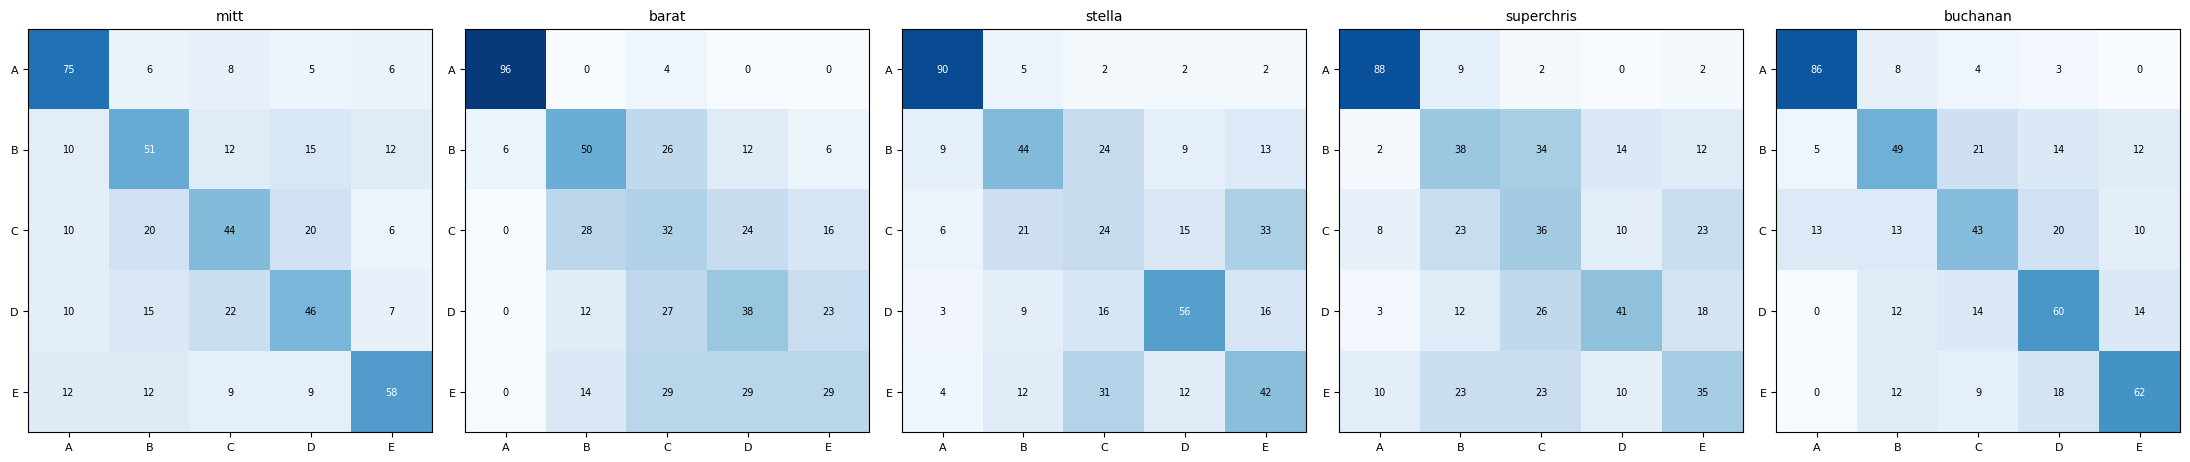

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
odor_labels = ['A', 'B', 'C', 'D', 'E']
for ax, session_name in zip(axes, final_results):
    cm_pct = final_results[session_name]['confusion_matrix_pct']
    ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels(odor_labels, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(odor_labels, fontsize=8)
    ax.set_title(session_name.split('_')[1], fontsize=10)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm_pct[i, j]:.0f}%', ha='center', va='center',
                     color='white' if cm_pct[i, j] > 50 else 'black', fontsize=7)
plt.tight_layout()
plt.show()


## Part E: Compare Against Notebook 021's Single-Guess Odor Identity Window

Notebook 021 used Poke-In, 0ms, 1500ms for every rat without searching alternatives. This checks
whether the search actually found something better, or whether notebook 021's original guess was
already fine (in which case that's a legitimate, useful finding too, it means the extra search
effort confirms robustness rather than uncovering a hidden improvement).


In [8]:
old_odor_tuned = {'080718_mitt': 0.5139, '081106_barat': 0.5015, '090212_stella': 0.504,
                   '090212_superchris': 0.4817, '090420_buchanan': 0.5993}  # from notebook021_universal_window_results.json

print(f"{'Rat':22s} {'Old (nb021)':14s} {'New (this nb)':14s} {'Change':8s}")
print("-" * 60)
for session_name in final_results:
    old = old_odor_tuned[session_name]
    new = final_results[session_name]['balanced_accuracy']
    print(f"{session_name:22s} {old:<14.4f} {new:<14.4f} {new - old:+.4f}")


Rat                    Old (nb021)    New (this nb)  Change  
------------------------------------------------------------
080718_mitt            0.5139         0.5139         -0.0000
081106_barat           0.5015         0.5015         -0.0000
090212_stella          0.5040         0.5040         +0.0000
090212_superchris      0.4817         0.4817         +0.0000
090420_buchanan        0.5993         0.5993         +0.0000


## Part F: Text-Only Results Export


In [9]:
import json as _json
import os

export_summary = {
    "purpose": "Automated Odor Identity window search (8 candidates, Poke-In referenced), winner chosen by Mitt/Buchanan priority rule",
    "screening_results": screening_results,
    "winning_config": winning_config,
    "comparison_to_notebook021": {
        session_name: {
            "old_balanced_accuracy": old_odor_tuned[session_name],
            "new_balanced_accuracy": round(float(final_results[session_name]['balanced_accuracy']), 4),
        }
        for session_name in final_results
    },
    "final_results": {
        session_name: {
            "balanced_accuracy": round(float(r['balanced_accuracy']), 4),
            "auc_ovr": round(float(r['auc_ovr']), 4),
            "p_value": round(float(r['p_value']), 6),
            "confusion_matrix_percent": r['confusion_matrix_pct'].round(1).tolist(),
        }
        for session_name, r in final_results.items()
    },
}

print(_json.dumps(export_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook023_odor_window_search_results.json', 'w') as f:
    _json.dump(export_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook023_odor_window_search_results.json")


{
  "purpose": "Automated Odor Identity window search (8 candidates, Poke-In referenced), winner chosen by Mitt/Buchanan priority rule",
  "screening_results": {
    "pokein_0_750": {
      "080718_mitt": 0.40254545454545454,
      "081106_barat": 0.4968571428571428,
      "090212_stella": 0.45706204906204906,
      "090212_superchris": 0.42376623376623374,
      "090420_buchanan": 0.4997777777777778
    },
    "pokein_0_1000": {
      "080718_mitt": 0.45885353535353535,
      "081106_barat": 0.534,
      "090212_stella": 0.4972987012987013,
      "090212_superchris": 0.4953246753246753,
      "090420_buchanan": 0.5883174603174604
    },
    "pokein_0_1500": {
      "080718_mitt": 0.5473340548340548,
      "081106_barat": 0.488,
      "090212_stella": 0.5152178932178932,
      "090212_superchris": 0.47472294372294377,
      "090420_buchanan": 0.5997301587301587
    },
    "pokein_0_1750": {
      "080718_mitt": 0.5302135642135642,
      "081106_barat": 0.4820952380952381,
      "090212

## Part G: Written Summary Report

Objective

Give Odor Identity the same window-search treatment InSeq/OutSeq got in notebook 022, rather than
carrying forward notebook 021's single untested guess, using the same Mitt/Buchanan priority rule
for consistency across both tasks.

Method

8 candidate windows, all Poke-In referenced (per the advisor's guidance that Odor Identity should use
a different, earlier, shorter window than InSeq/OutSeq's behavioral-response window), tested via fast
5-fold screening across all 5 rats. Winner selected by maximizing the minimum of Mitt's and Buchanan's
scores. The winner was then re-evaluated with full rigor, repeated cross-validation, one-vs-rest AUC,
confusion matrix, and permutation testing.

Results

(Fill in after running.) Which candidate won? Did it actually beat notebook 021's guessed window for
Mitt and Buchanan without hurting the others?

Next Steps

1. Adopt this window (or confirm notebook 021's original guess) as the final Odor Identity window for
   the presentation.
2. Redo interpretability at both final windows, InSeq/OutSeq (notebook 022's winner) and Odor Identity
   (this notebook's winner).
3. Assemble the final presentation notebook.
